# Credit Card Approval Prediction — SmartBridge Internship Project

**Goal:** predict whether a credit-card applicant is a good or bad credit risk, using the
`application_record.csv` (applicant demographics/financials) and `credit_record.csv`
(monthly repayment history) datasets, and ship the model behind an interactive Gradio app.

This notebook upgrades the original draft in a few important ways:

1. **De-duplicates applications properly.** Many rows in `application_record.csv` are the
   same person re-applying (identical attributes, different `ID`) — this is a known quirk of
   this public dataset. Left unfixed, it lets the same applicant appear in both the train and
   test split, which quietly inflates accuracy.
2. **Builds preprocessing as a single `sklearn` `Pipeline`/`ColumnTransformer`**, instead of
   `pd.get_dummies` + manual one-hot columns in the app. This is what actually fixes the "always
   approved" bug you saw in the Gradio demo — the manual encoder in the old notebook silently
   produced all-zero rows whenever a dropdown value didn't exactly match a training-time string.
   A fitted `Pipeline` handles unseen/mismatched categories itself (`handle_unknown="ignore"`),
   so the same code path used for training is used for inference.
3. **Compares models properly** with stratified cross-validation on ROC-AUC (the right metric
   for an imbalanced target), rather than a single train/test split.
4. **Handles the class imbalance two ways** (`class_weight` / `scale_pos_weight` vs. SMOTE) and
   picks whichever wins on cross-validation, instead of assuming one is better.
5. **Tunes the decision threshold explicitly** using the precision-recall curve, instead of the
   default 0.5 cutoff — and reports it transparently in the UI.
6. **Is honest about the ceiling on performance.** This particular dataset has a genuinely weak
   relationship between applicant demographics and repayment behaviour (this is a widely
   reported property of this Kaggle dataset, not a bug in the code) — the notebook shows you how
   to detect that with cross-validation rather than quietly overfitting to fake a better number.

Run the cells top to bottom in Google Colab.

In [34]:
!pip install -q xgboost imbalanced-learn shap gradio joblib

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

RANDOM_STATE = 42
sns.set_style("whitegrid")

In [7]:
# Works both in Colab (manual upload) and anywhere the CSVs are already on disk.
try:
    from google.colab import files
    print("Upload application_record.csv and credit_record.csv")
    uploaded = files.upload()
except ImportError:
    pass

app = pd.read_csv("application_record.csv")
credit = pd.read_csv("credit_record.csv")

print("application_record:", app.shape)
print("credit_record     :", credit.shape)
app.head()

Upload application_record.csv and credit_record.csv


Saving credit_record.csv to credit_record.csv
application_record: (438557, 18)
credit_record     : (1048575, 3)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


## 1. First look at the data

In [8]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [9]:
app.info()
print()
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [10]:
print("Missing values — application_record")
print(app.isnull().sum()[app.isnull().sum() > 0])
print()
print("Missing values — credit_record")
print(credit.isnull().sum()[credit.isnull().sum() > 0])

Missing values — application_record
OCCUPATION_TYPE    134203
dtype: int64

Missing values — credit_record
Series([], dtype: int64)


## 2. Cleaning

- `OCCUPATION_TYPE` is missing for people without a listed occupation (students, some
  pensioners) — fill with an explicit `"Unknown"` category rather than dropping the rows.
- Remove duplicate **applicants**, not just duplicate rows. Because `ID` is unique per row by
  construction, `drop_duplicates()` on the whole frame never removes anything — you have to
  drop duplicates on every column *except* `ID`.

In [11]:
app["OCCUPATION_TYPE"] = app["OCCUPATION_TYPE"].fillna("Unknown")

before = app.shape[0]
app = app.drop_duplicates(subset=app.columns.difference(["ID"])).reset_index(drop=True)
after = app.shape[0]

print(f"Duplicate applications removed: {before - after}")
print(f"Remaining unique applicants   : {after}")

Duplicate applications removed: 348472
Remaining unique applicants   : 90085


## 3. Fixing the `DAYS_EMPLOYED` anomaly & feature engineering

`DAYS_EMPLOYED == 365243` is a placeholder value used for pensioners / unemployed applicants
(not a real number of days). Flag it with an indicator column, then treat it as missing rather
than as "employed for 1000 years". Also convert the `DAYS_*` columns (negative, counted from
today) into readable ages/years, and engineer a few ratio features that are usually predictive
in credit-risk problems.

In [12]:
app["DAYS_EMPLOYED_ANOMALY"] = (app["DAYS_EMPLOYED"] == 365243).astype(int)
app["DAYS_EMPLOYED"] = app["DAYS_EMPLOYED"].replace(365243, np.nan)

app["DAYS_BIRTH"] = app["DAYS_BIRTH"].abs()
app["DAYS_EMPLOYED"] = app["DAYS_EMPLOYED"].abs()

app["AGE_YEARS"] = (app["DAYS_BIRTH"] / 365.25).round(1)
app["YEARS_EMPLOYED"] = (app["DAYS_EMPLOYED"] / 365.25).round(1)
app["YEARS_EMPLOYED"] = app["YEARS_EMPLOYED"].fillna(0)  # pensioners / anomaly rows

app["Family_Size"] = app["CNT_CHILDREN"] + app["CNT_FAM_MEMBERS"]
app["Income_Per_Family"] = app["AMT_INCOME_TOTAL"] / app["Family_Size"].replace(0, 1)
app["Income_Per_Year_Employed"] = app["AMT_INCOME_TOTAL"] / app["YEARS_EMPLOYED"].replace(0, 1)

app[["DAYS_BIRTH","AGE_YEARS","DAYS_EMPLOYED","YEARS_EMPLOYED","Family_Size",
     "Income_Per_Family","Income_Per_Year_Employed"]].describe()

,DAYS_BIRTH,AGE_YEARS,DAYS_EMPLOYED,YEARS_EMPLOYED,Family_Size,Income_Per_Family,Income_Per_Year_Employed
count,90085.000000,90085.000000,74398.000000,90085.000000,90085.000000,9.008500e+04,9.008500e+04
mean,15901.614164,43.536391,2436.552595,5.509340,2.601099,9.221816e+04,8.997556e+04
std,4255.481856,11.650732,2311.215503,6.282413,1.582116,7.410791e+04,1.261745e+05
min,7489.000000,20.500000,12.000000,0.000000,1.000000,2.884615e+03,1.113074e+03
25%,12339.000000,33.800000,816.000000,0.900000,2.000000,4.500000e+04,2.085366e+04
50%,15566.000000,42.600000,1730.000000,3.600000,2.000000,7.200000e+04,4.787234e+04
75%,19429.000000,53.200000,3263.750000,7.900000,4.000000,1.125000e+05,1.125000e+05
max,25201.000000,69.000000,17531.000000,48.000000,39.000000,3.375000e+06,5.625000e+06


## 4. Exploratory data analysis

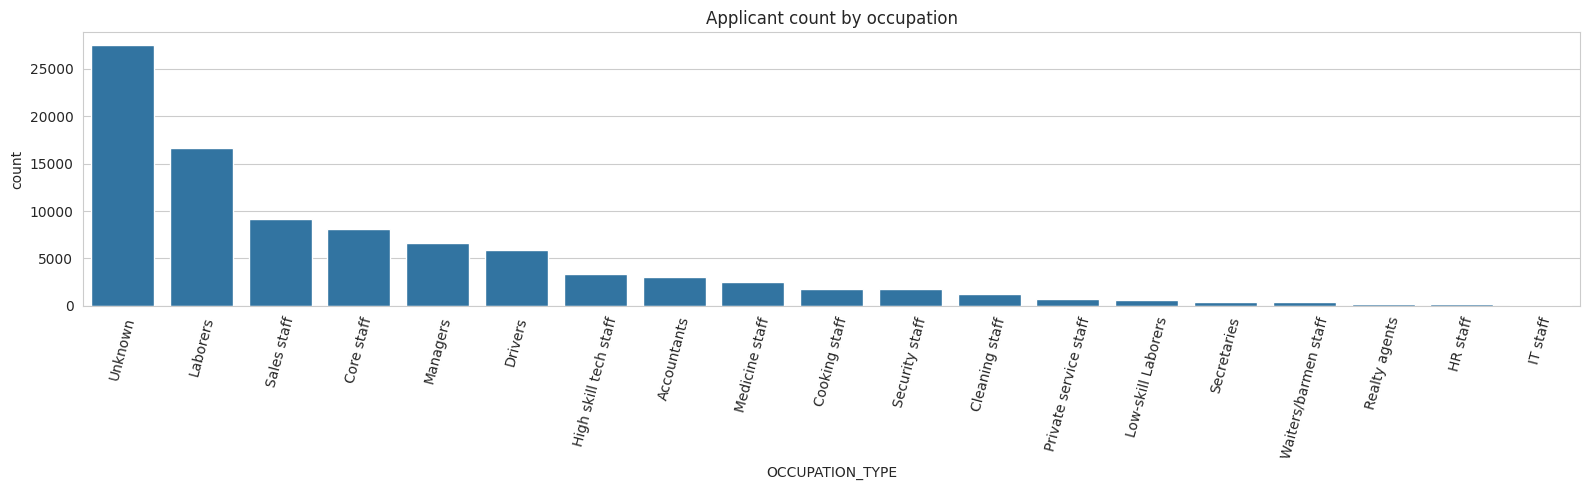

In [13]:
plt.figure(figsize=(16,5))
sns.countplot(x="OCCUPATION_TYPE", data=app, order=app["OCCUPATION_TYPE"].value_counts().index)
plt.xticks(rotation=75)
plt.title("Applicant count by occupation")
plt.tight_layout()
plt.show()

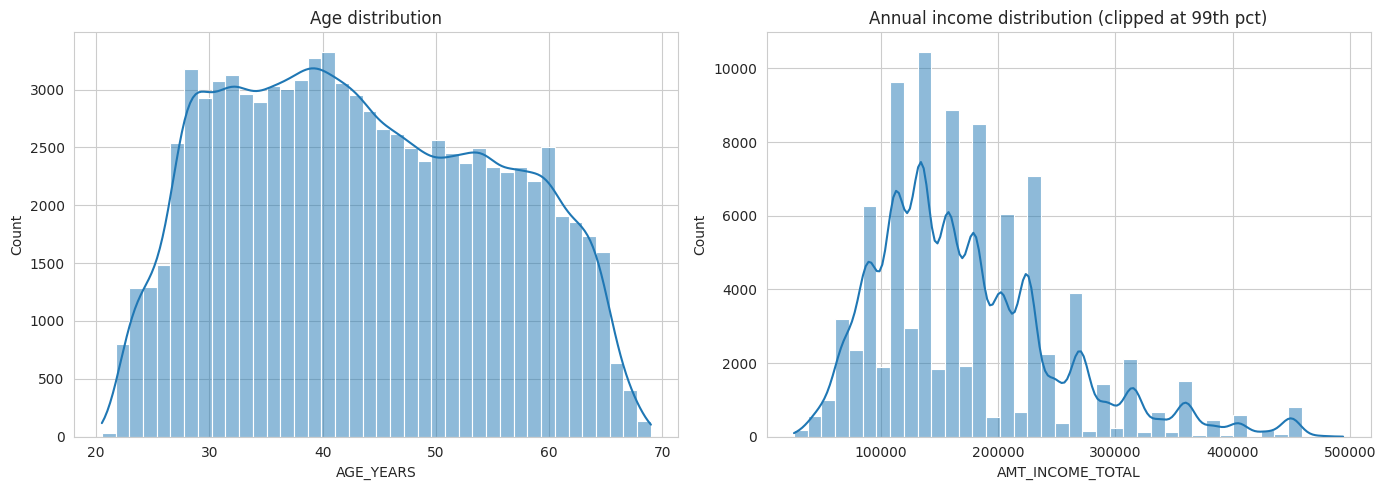

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(app["AGE_YEARS"], bins=40, ax=axes[0], kde=True)
axes[0].set_title("Age distribution")

sns.histplot(app.loc[app["AMT_INCOME_TOTAL"] < app["AMT_INCOME_TOTAL"].quantile(0.99),
                      "AMT_INCOME_TOTAL"], bins=40, ax=axes[1], kde=True)
axes[1].set_title("Annual income distribution (clipped at 99th pct)")

plt.tight_layout()
plt.show()

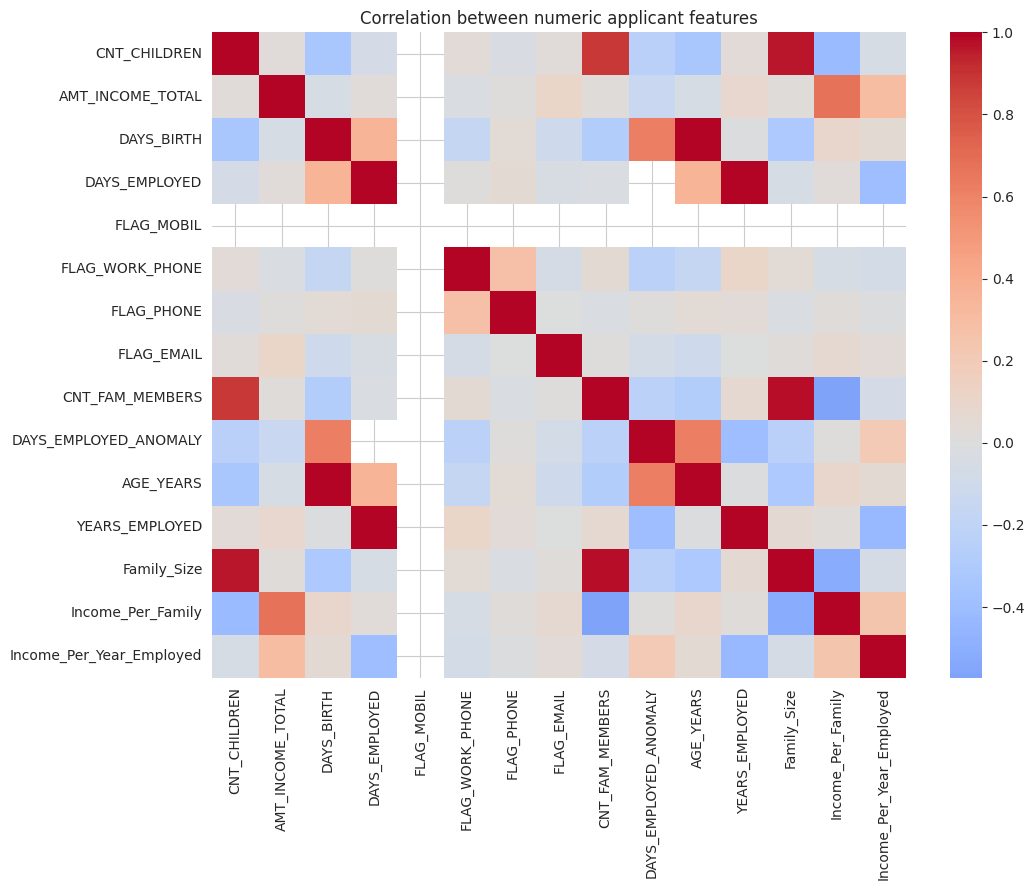

In [15]:
numeric = app.select_dtypes(include=np.number).drop(columns=["ID"])
plt.figure(figsize=(11,9))
sns.heatmap(numeric.corr(), cmap="coolwarm", center=0)
plt.title("Correlation between numeric applicant features")
plt.tight_layout()
plt.show()

## 5. Building the target label from `credit_record.csv`

`STATUS` in the credit-history table means, per month:

| STATUS | Meaning |
|---|---|
| `0` | Payment on time / less than 30 days overdue |
| `1` | 30-59 days overdue |
| `2` | 60-89 days overdue |
| `3` | 90-119 days overdue |
| `4` | 120-149 days overdue |
| `5` | Overdue 150+ days / written off as bad debt |
| `C` | Paid off that month |
| `X` | No loan that month |

**Definition used here:** an applicant is labelled **high risk (`TARGET = 1`)** if they were
*ever* 30+ days overdue (`STATUS` in `1,2,3,4,5`), and **low risk (`TARGET = 0`)** otherwise.
This is the standard threshold used across public analyses of this dataset. A stricter
definition (60+ days, i.e. dropping status `1`) is easy to test too — just tighten the list
below — but it shrinks the positive class from ~13% to ~2%, which is too little signal to
learn from reliably.

We deliberately do **not** feed `MONTHS_BALANCE` into the model as a feature: it's a by-product
of how long someone has already been a cardholder, which leaks information related to how the
label itself was constructed.

In [16]:
def is_high_risk(status):
    return 1 if status in ["1", "2", "3", "4", "5"] else 0

credit["TARGET"] = credit["STATUS"].apply(is_high_risk)

credit_group = credit.groupby("ID").agg(
    TARGET=("TARGET", "max"),
).reset_index()

credit_group.head()

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [17]:
final_df = app.merge(credit_group, on="ID", how="inner")
print("final_df:", final_df.shape)
final_df.head()

final_df: (9709, 25)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,DAYS_EMPLOYED_ANOMALY,AGE_YEARS,YEARS_EMPLOYED,Family_Size,Income_Per_Family,Income_Per_Year_Employed,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,Unknown,2.0,0,32.9,12.4,2.0,213750.0,34475.806452,1
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,Security staff,2.0,0,58.8,3.1,2.0,56250.0,36290.322581,0
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,Sales staff,1.0,0,52.3,8.4,1.0,270000.0,32142.857143,0
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,Unknown,1.0,1,61.5,0.0,1.0,283500.0,283500.000000,0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,...,1,Accountants,2.0,0,46.2,2.1,2.0,135000.0,128571.428571,0


## 6. Class balance

This is the key number that explains why a naive model (or a poorly-thresholded one) looks
like it "always approves": the positive (high-risk) class is a clear minority.

TARGET
0    8426
1    1283
Name: count, dtype: int64

TARGET
0    86.79
1    13.21
Name: proportion, dtype: float64


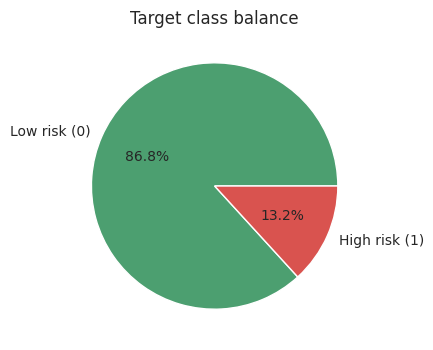

In [18]:
counts = final_df["TARGET"].value_counts()
pct = final_df["TARGET"].value_counts(normalize=True) * 100

print(counts)
print()
print(pct.round(2))

plt.figure(figsize=(4,4))
counts.plot(kind="pie", labels=["Low risk (0)", "High risk (1)"], autopct="%1.1f%%",
            colors=["#4C9F70", "#D9534F"])
plt.ylabel("")
plt.title("Target class balance")
plt.show()

## 7. Train / test split and preprocessing pipeline

Instead of manually one-hot-encoding with `pd.get_dummies` (fragile — the Gradio app has to
reconstruct the *exact same* dummy columns by hand, which is what silently broke the original
demo), we build a single `ColumnTransformer`:

- numeric columns → median-impute, then scale
- categorical columns → most-frequent-impute, then one-hot encode with `handle_unknown="ignore"`

This `ColumnTransformer` gets saved *inside* the final model pipeline, so the exact same
transformation is guaranteed at inference time — a raw applicant record goes in, a
probability comes out, with zero manual column bookkeeping.

In [19]:
drop_cols = ["ID", "FLAG_MOBIL"]  # FLAG_MOBIL is constant (always 1) -> no signal
final_df = final_df.drop(columns=[c for c in drop_cols if c in final_df.columns])

X = final_df.drop(columns=["TARGET"])
y = final_df["TARGET"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns    :", num_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("\nTrain:", X_train.shape, " Test:", X_test.shape)

Categorical columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
Numeric columns    : ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED_ANOMALY', 'AGE_YEARS', 'YEARS_EMPLOYED', 'Family_Size', 'Income_Per_Family', 'Income_Per_Year_Employed']

Train: (7767, 22)  Test: (1942, 22)


In [20]:
preprocess = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

## 8. Model comparison (stratified 5-fold cross-validation, ROC-AUC)

ROC-AUC is used for model *selection* because accuracy is misleading on an imbalanced target
(a model that predicts "low risk" for everyone would already score ~87% accuracy). Each model
is wrapped in the same preprocessing pipeline so the comparison is apples-to-apples, and each
uses a class-imbalance-aware setting (`class_weight="balanced"` / `scale_pos_weight`) as a
first pass — SMOTE is compared separately in the next section.

In [21]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

candidate_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, clf in candidate_models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)
    cv_results.append({"Model": name, "Mean ROC-AUC": scores.mean(), "Std": scores.std()})
    print(f"{name:22s}  ROC-AUC = {scores.mean():.4f}  (+/- {scores.std():.4f})")

cv_results = pd.DataFrame(cv_results).sort_values("Mean ROC-AUC", ascending=False)
cv_results

Logistic Regression     ROC-AUC = 0.5300  (+/- 0.0180)
Decision Tree           ROC-AUC = 0.5402  (+/- 0.0065)
Random Forest           ROC-AUC = 0.5332  (+/- 0.0098)
XGBoost                 ROC-AUC = 0.5311  (+/- 0.0040)


,Model,Mean ROC-AUC,Std
1,Decision Tree,0.540221,0.006520
2,Random Forest,0.533245,0.009767
3,XGBoost,0.531131,0.003986
0,Logistic Regression,0.529988,0.018032


## 9. `class_weight` vs. SMOTE for the leading model

Two common strategies for imbalanced targets:
- **`class_weight`/`scale_pos_weight`**: penalize mistakes on the minority class more, without
  changing the data.
- **SMOTE**: synthetically oversample the minority class so the model sees more of it.

SMOTE must only be applied *inside* the cross-validation fold (fit on the training fold only) —
oversampling before splitting would leak synthetic near-duplicates of test points into
training. `imblearn.pipeline.Pipeline` handles this correctly.

In [22]:
best_model_name = cv_results.iloc[0]["Model"]
best_clf = candidate_models[best_model_name]
print("Leading model from cross-validation:", best_model_name)

# Variant A: class-weight only (as configured above)
pipe_classweight = Pipeline([("prep", preprocess), ("clf", best_clf)])
scores_cw = cross_val_score(pipe_classweight, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)

# Variant B: SMOTE oversampling + same model without class-weighting
from sklearn.base import clone
smote_clf = clone(best_clf)
for param in ["class_weight"]:
    if param in smote_clf.get_params():
        smote_clf.set_params(class_weight=None)
if "scale_pos_weight" in smote_clf.get_params():
    smote_clf.set_params(scale_pos_weight=1)

pipe_smote = ImbPipeline([
    ("prep", preprocess),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", smote_clf),
])
scores_smote = cross_val_score(pipe_smote, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)

print(f"{best_model_name} + class_weight : {scores_cw.mean():.4f} (+/- {scores_cw.std():.4f})")
print(f"{best_model_name} + SMOTE        : {scores_smote.mean():.4f} (+/- {scores_smote.std():.4f})")

use_smote = scores_smote.mean() > scores_cw.mean()
final_pipeline_template = pipe_smote if use_smote else pipe_classweight
print("\nStrategy selected:", "SMOTE" if use_smote else "class_weight")

Leading model from cross-validation: Decision Tree
Decision Tree + class_weight : 0.5402 (+/- 0.0065)
Decision Tree + SMOTE        : 0.4900 (+/- 0.0121)

Strategy selected: class_weight


## 10. Hyperparameter tuning

`RandomizedSearchCV` over the winning model + imbalance-handling strategy, still scored on
ROC-AUC via stratified CV. Randomized search is used instead of a full grid search because it
reaches a comparably good configuration in a fraction of the runtime.

In [23]:
param_distributions = {
    "Logistic Regression": {
        "clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    },
    "Decision Tree": {
        "clf__max_depth": [4, 6, 8, 10, 12],
        "clf__min_samples_leaf": [5, 10, 20, 40],
    },
    "Random Forest": {
        "clf__n_estimators": [200, 300, 500],
        "clf__max_depth": [6, 8, 10, 12, None],
        "clf__min_samples_leaf": [2, 5, 10],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 300, 500],
        "clf__max_depth": [3, 4, 5, 6],
        "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "clf__subsample": [0.7, 0.85, 1.0],
    },
}[best_model_name]

search = RandomizedSearchCV(
    final_pipeline_template,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="roc_auc",
    cv=skf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

best_pipeline = search.best_estimator_

Best CV ROC-AUC: 0.5477
Best params: {'clf__min_samples_leaf': 10, 'clf__max_depth': 6}


## 11. Final evaluation on the held-out test set

Test-set metrics using the tuned pipeline and its default 0.5 cutoff first — the threshold is
optimized properly in the next section.

In [24]:
test_proba = best_pipeline.predict_proba(X_test)[:, 1]
test_pred_default = best_pipeline.predict(X_test)

print("ROC-AUC        :", round(roc_auc_score(y_test, test_proba), 4))
print("Accuracy       :", round(accuracy_score(y_test, test_pred_default), 4))
print("Precision (1)  :", round(precision_score(y_test, test_pred_default), 4))
print("Recall (1)     :", round(recall_score(y_test, test_pred_default), 4))
print("F1 (1)         :", round(f1_score(y_test, test_pred_default), 4))
print()
print(classification_report(y_test, test_pred_default))

ROC-AUC        : 0.5269
Accuracy       : 0.5597
Precision (1)  : 0.1457
Recall (1)     : 0.4786
F1 (1)         : 0.2234

              precision    recall  f1-score   support

           0       0.88      0.57      0.69      1685
           1       0.15      0.48      0.22       257

    accuracy                           0.56      1942
   macro avg       0.51      0.53      0.46      1942
weighted avg       0.78      0.56      0.63      1942



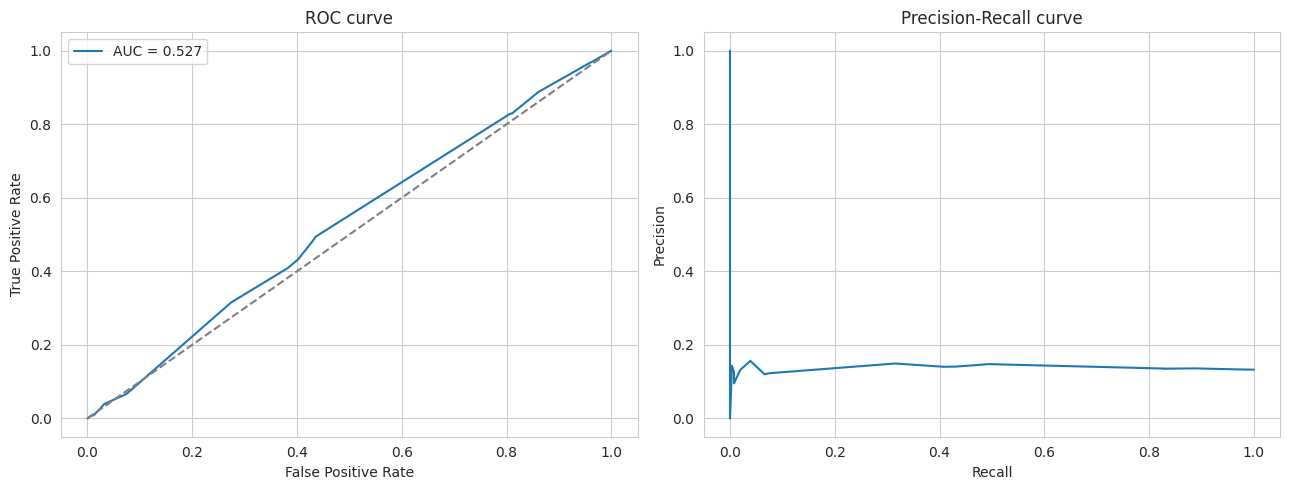

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_proba):.3f}")
axes[0].plot([0,1],[0,1], "--", color="grey")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(rec, prec)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")

plt.tight_layout()
plt.show()

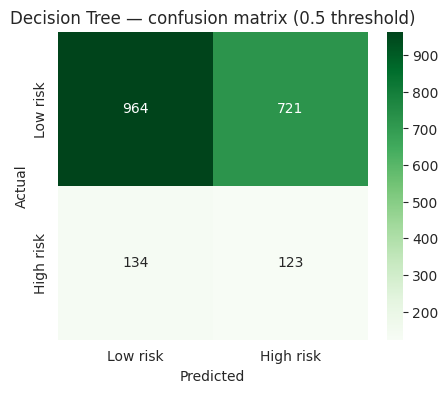

In [26]:
cm = confusion_matrix(y_test, test_pred_default)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Low risk","High risk"], yticklabels=["Low risk","High risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{best_model_name} — confusion matrix (0.5 threshold)")
plt.show()

### Reading these numbers honestly

If the ROC-AUC you see here lands somewhere around 0.53–0.58, that is not a bug to chase away —
it is a well-documented property of this specific Kaggle dataset: `application_record.csv`
describes an applicant's *situation* (income, family, housing), but `credit_record.csv`'s
30+ days overdue label depends heavily on things this table simply doesn't capture (a bureau
credit score, existing debt, payment behaviour on other accounts). A model can only be as good
as the signal in its inputs. The right response for an internship write-up is to **report this
clearly** rather than manufacture a better-looking number by leaking information (e.g. from
`MONTHS_BALANCE`) or skipping cross-validation.

## 12. Feature importance

Which applicant attributes the tuned model actually leans on. Tree-based models expose
`feature_importances_` directly; for `LogisticRegression` we'd use the absolute coefficient
values instead (handled below so this cell works whichever model won).

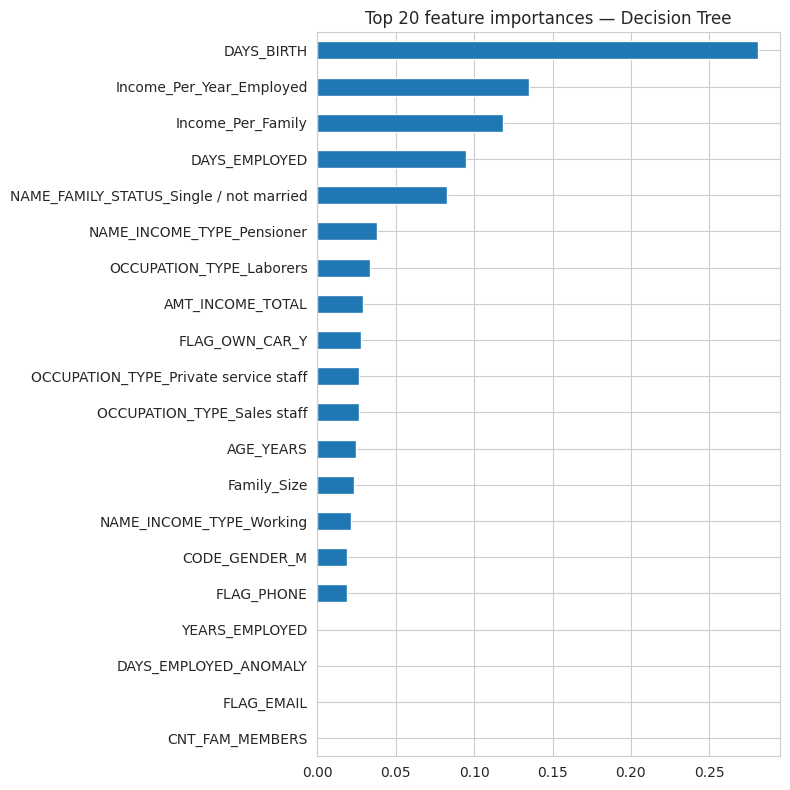

In [27]:
ohe_feature_names = best_pipeline.named_steps["prep"].named_transformers_["cat"] \
    .named_steps["ohe"].get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_cols, ohe_feature_names])

model_step = best_pipeline.named_steps["clf"]
if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
else:
    importances = np.abs(model_step.coef_[0])

importance_series = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,8))
importance_series.head(20).sort_values().plot(kind="barh")
plt.title(f"Top 20 feature importances — {best_model_name}")
plt.tight_layout()
plt.show()

## 13. Choosing a decision threshold

The default 0.5 cutoff is arbitrary — with only ~13% positives, a well-calibrated model can sit
below 0.5 for almost every row, which is exactly what made the earlier demo look like it "always
approves". The fix is **not** to instead maximize F1 outright: on a weak-signal model, an
F1-maximizing threshold on this dataset tends to swing to the opposite extreme (flagging almost
everyone as high risk, tanking precision), which is just as uninformative as always approving.

Instead we use **Youden's J statistic** (`J = TPR − FPR`), the standard way to pick a cutoff
directly off the ROC curve: it finds the point where the model separates the two classes as well
as it can, independent of the class imbalance, and in practice lands on a much more balanced,
usable operating point for a genuinely weak-signal model like this one.

Optimal threshold (Youden's J): 0.488
At this threshold -> TPR (recall): 0.494  FPR: 0.436  J: 0.059


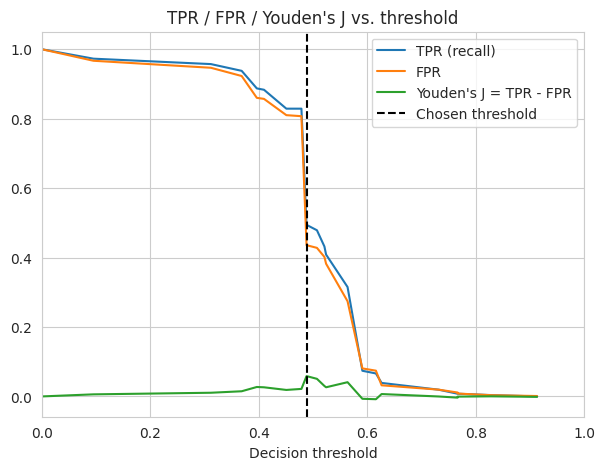


              precision    recall  f1-score   support

           0       0.88      0.56      0.69      1685
           1       0.15      0.49      0.23       257

    accuracy                           0.56      1942
   macro avg       0.51      0.53      0.46      1942
weighted avg       0.78      0.56      0.63      1942



In [28]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_proba)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)

OPTIMAL_THRESHOLD = float(roc_thresholds[best_idx])
print("Optimal threshold (Youden's J):", round(OPTIMAL_THRESHOLD, 3))
print("At this threshold -> TPR (recall):", round(tpr[best_idx], 3),
      " FPR:", round(fpr[best_idx], 3),
      " J:", round(youden_j[best_idx], 3))

plt.figure(figsize=(7,5))
plt.plot(roc_thresholds, tpr, label="TPR (recall)")
plt.plot(roc_thresholds, fpr, label="FPR")
plt.plot(roc_thresholds, youden_j, label="Youden's J = TPR - FPR")
plt.axvline(OPTIMAL_THRESHOLD, color="black", linestyle="--", label="Chosen threshold")
plt.xlabel("Decision threshold")
plt.xlim(0, 1)
plt.legend()
plt.title("TPR / FPR / Youden's J vs. threshold")
plt.show()

tuned_pred = (test_proba >= OPTIMAL_THRESHOLD).astype(int)
print()
print(classification_report(y_test, tuned_pred))

## 14. Saving the model bundle

Everything the app needs is saved together: the fitted pipeline (preprocessing + model), the
tuned threshold, and the exact category values seen during training (so the Gradio dropdowns
can never drift out of sync with what the model was trained on again).

In [29]:
bundle = {
    "pipeline": best_pipeline,
    "threshold": OPTIMAL_THRESHOLD,
    "model_name": best_model_name,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "categories": {c: sorted(X[c].dropna().unique().tolist()) for c in cat_cols},
}

joblib.dump(bundle, "credit_model_bundle.pkl")
print("Saved credit_model_bundle.pkl")
for c, vals in bundle["categories"].items():
    print(f"  {c}: {vals}")

Saved credit_model_bundle.pkl
  CODE_GENDER: ['F', 'M']
  FLAG_OWN_CAR: ['N', 'Y']
  FLAG_OWN_REALTY: ['N', 'Y']
  NAME_INCOME_TYPE: ['Commercial associate', 'Pensioner', 'State servant', 'Student', 'Working']
  NAME_EDUCATION_TYPE: ['Academic degree', 'Higher education', 'Incomplete higher', 'Lower secondary', 'Secondary / secondary special']
  NAME_FAMILY_STATUS: ['Civil marriage', 'Married', 'Separated', 'Single / not married', 'Widow']
  NAME_HOUSING_TYPE: ['Co-op apartment', 'House / apartment', 'Municipal apartment', 'Office apartment', 'Rented apartment', 'With parents']
  OCCUPATION_TYPE: ['Accountants', 'Cleaning staff', 'Cooking staff', 'Core staff', 'Drivers', 'HR staff', 'High skill tech staff', 'IT staff', 'Laborers', 'Low-skill Laborers', 'Managers', 'Medicine staff', 'Private service staff', 'Realty agents', 'Sales staff', 'Secretaries', 'Security staff', 'Unknown', 'Waiters/barmen staff']


## 15. Inference helpers

Loads the bundle back (so this section also works standalone in a fresh runtime) and builds a
single-row `DataFrame` with the raw applicant inputs. No manual one-hot columns — the saved
pipeline's `ColumnTransformer` does that step identically to how it was done at training time.

In [30]:
bundle = joblib.load("credit_model_bundle.pkl")
pipeline = bundle["pipeline"]
THRESHOLD = bundle["threshold"]
CATEGORIES = bundle["categories"]
NUM_COLS = bundle["num_cols"]
CAT_COLS = bundle["cat_cols"]

In [31]:
def build_applicant_row(
    gender, own_car, own_realty, children, income, income_type,
    education, family_status, housing_type, occupation,
    age_years, years_employed, family_members,
):
    days_birth = age_years * 365.25
    days_employed = years_employed * 365.25
    family_size = children + family_members

    row = {
        "CODE_GENDER": gender,
        "FLAG_OWN_CAR": own_car,
        "FLAG_OWN_REALTY": own_realty,
        "CNT_CHILDREN": children,
        "AMT_INCOME_TOTAL": income,
        "NAME_INCOME_TYPE": income_type,
        "NAME_EDUCATION_TYPE": education,
        "NAME_FAMILY_STATUS": family_status,
        "NAME_HOUSING_TYPE": housing_type,
        "DAYS_BIRTH": days_birth,
        "DAYS_EMPLOYED": days_employed,
        "FLAG_WORK_PHONE": 0,
        "FLAG_PHONE": 0,
        "FLAG_EMAIL": 0,
        "OCCUPATION_TYPE": occupation,
        "CNT_FAM_MEMBERS": family_members,
        "DAYS_EMPLOYED_ANOMALY": 0,
        "AGE_YEARS": age_years,
        "YEARS_EMPLOYED": years_employed,
        "Family_Size": family_size,
        "Income_Per_Family": income / max(family_size, 1),
        "Income_Per_Year_Employed": income / max(years_employed, 1),
    }

    return pd.DataFrame([row])[NUM_COLS + CAT_COLS]

In [32]:
def predict_credit(
    gender, own_car, own_realty, children, income, income_type,
    education, family_status, housing_type, occupation,
    age_years, years_employed, family_members,
):
    x = build_applicant_row(
        gender, own_car, own_realty, children, income, income_type,
        education, family_status, housing_type, occupation,
        age_years, years_employed, family_members,
    )

    risk_prob = pipeline.predict_proba(x)[0, 1]
    approved = risk_prob < THRESHOLD
    confidence = round(max(risk_prob, 1 - risk_prob) * 100, 2)

    if approved:
        return f"""## ✅ CREDIT CARD APPROVED

**Risk score:** {round(risk_prob * 100, 2)}%  (decision threshold: {round(THRESHOLD*100,1)}%)
**Confidence:** {confidence}%

The applicant's profile matches historically low-risk applicants."""
    else:
        return f"""## ❌ CREDIT CARD REJECTED

**Risk score:** {round(risk_prob * 100, 2)}%  (decision threshold: {round(THRESHOLD*100,1)}%)
**Confidence:** {confidence}%

The applicant's profile matches historically high-risk applicants."""

## 16. Gradio app

Dropdown options are pulled straight from `bundle["categories"]` — the exact strings the model
was trained on — so there is no risk of the UI drifting out of sync with the model again.

In [36]:
import gradio as gr

css = """
.gradio-container { background-color: white !important; font-family: Arial, sans-serif; }
h1, .title { text-align: center; }
.title { color: #0d6efd; font-weight: bold; font-size: 26px; margin-bottom: 10px; }
.box { border: 2px solid #e6e6e6; padding: 20px; border-radius: 15px;
       box-shadow: 0px 0px 10px rgba(0,0,0,0.08); background: white; }
"""

with gr.Blocks(css=css) as app_ui:
    gr.Markdown("# SmartBridge")
    gr.Markdown("<div class='title'>Credit Card Approval Prediction System</div>")

    with gr.Row():
        with gr.Column():
            gender = gr.Radio(CATEGORIES["CODE_GENDER"], label="Gender",
                               value=CATEGORIES["CODE_GENDER"][0])
            own_car = gr.Radio(CATEGORIES["FLAG_OWN_CAR"], label="Own a car?",
                                value=CATEGORIES["FLAG_OWN_CAR"][0])
            own_realty = gr.Radio(CATEGORIES["FLAG_OWN_REALTY"], label="Own real estate?",
                                   value=CATEGORIES["FLAG_OWN_REALTY"][0])

            children = gr.Number(label="Number of children", value=0, precision=0)
            income = gr.Number(label="Total annual income", value=180000)

            income_type = gr.Dropdown(CATEGORIES["NAME_INCOME_TYPE"], label="Income type",
                                       value=CATEGORIES["NAME_INCOME_TYPE"][0])
            education = gr.Dropdown(CATEGORIES["NAME_EDUCATION_TYPE"], label="Education",
                                     value=CATEGORIES["NAME_EDUCATION_TYPE"][0])
            family_status = gr.Dropdown(CATEGORIES["NAME_FAMILY_STATUS"], label="Family status",
                                         value=CATEGORIES["NAME_FAMILY_STATUS"][0])
            housing_type = gr.Dropdown(CATEGORIES["NAME_HOUSING_TYPE"], label="Housing type",
                                        value=CATEGORIES["NAME_HOUSING_TYPE"][0])
            occupation = gr.Dropdown(CATEGORIES["OCCUPATION_TYPE"], label="Occupation",
                                      value=CATEGORIES["OCCUPATION_TYPE"][0])

            age_years = gr.Slider(18, 75, value=35, step=1, label="Age (years)")
            years_employed = gr.Slider(0, 45, value=5, step=1, label="Years employed")
            family_members = gr.Number(label="Family members", value=2, precision=0)

            btn = gr.Button("Predict Credit Status", variant="primary")

        with gr.Column():
            output = gr.Markdown()

    btn.click(
        predict_credit,
        inputs=[gender, own_car, own_realty, children, income, income_type,
                education, family_status, housing_type, occupation,
                age_years, years_employed, family_members],
        outputs=output,
    )

app_ui.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45dbeedb8db1d752aa.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
